In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# 파일 선택
test_path = '/kaggle/input/competitions/titanic/test.csv'
train_path = '/kaggle/input/competitions/titanic/train.csv'

train_data = pd.read_csv(train_path)
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Text(0, 0.5, 'Percentage')

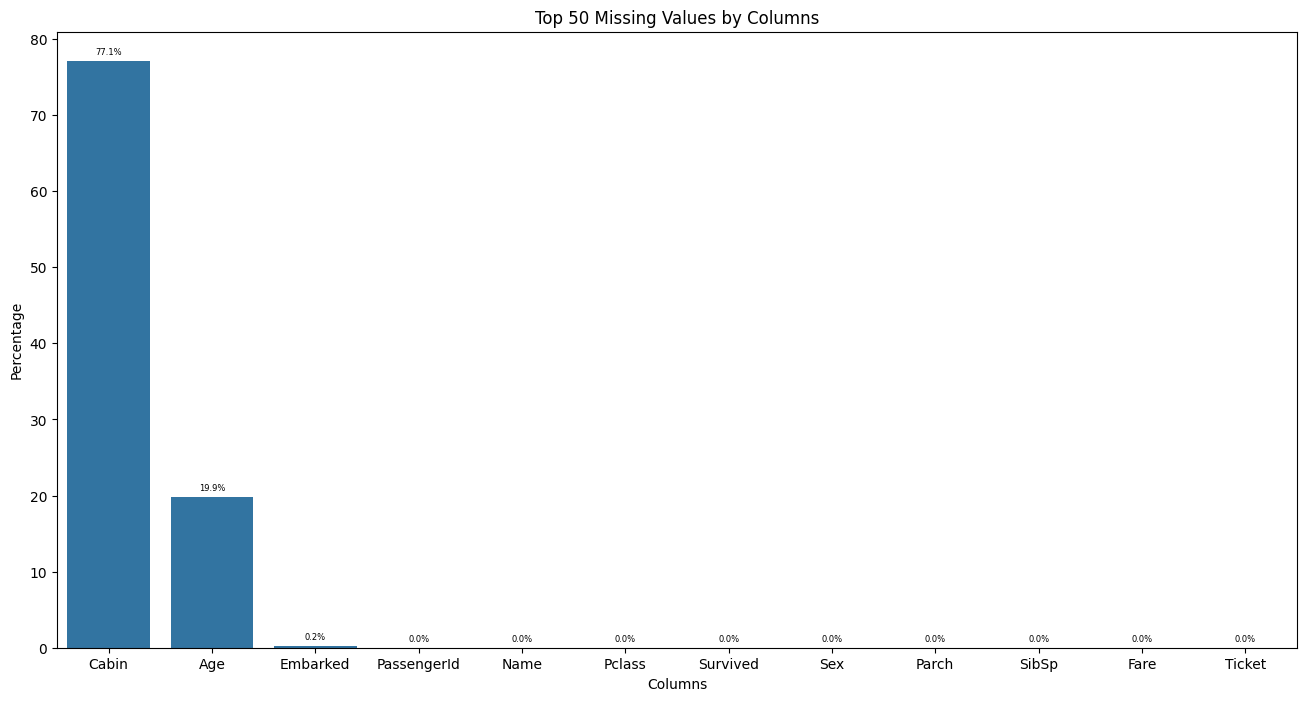

In [3]:
null_percent = train_data.isnull().mean()*100

null_top50 = null_percent.sort_values(ascending=False).head(50)

plt.figure(figsize=(16,8))

ax = sns.barplot(x=null_top50.index, y=null_top50.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)

plt.title("Top 50 Missing Values by Columns")
plt.xlabel("Columns")
plt.ylabel("Percentage")

In [4]:
# Cabin은 결측치 매우 높으므로 삭제
# Age는 호칭별 중앙값으로 대치
# Embarked는 대치 또는 행 삭제 중 고려

In [5]:
# 상수 열 확인
n_unique = train_data.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수열 개수: {len(constant_cols)}")
print(f"상수열 목록: {constant_cols.tolist()}")

상수열 개수: 0
상수열 목록: []


In [6]:
# Cabin열 삭제
train_dropped = train_data.drop(columns='Cabin')
print(f"Cabin 삭제 후 cloumns 수: {len(train_dropped.columns)}")


# Age열 대체(Name의 호칭 별 중앙값으로 대체)
# 호칭(Title) 추출
train_dropped['Title'] = train_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 호칭별 나이 중앙값 계산
title_age_median = train_dropped.groupby('Title')['Age'].transform('median')

# Age 결측치 중앙값으로 대체
train_dropped['Age'] = train_dropped['Age'].fillna(title_age_median)

# 확인
print(train_dropped[['Name', 'Title', 'Age']].head(10))


# Embarked 결측 행 삭제
print(f"Embarked 결측행 수: {train_dropped.isnull().sum().sum()}")
train_dropped2 = train_dropped.dropna(subset=['Embarked'])
print(f"Embarked 결측행 삭제 전 열 수: {len(train_dropped)}")
print(f"Embarked 결측행 삭제 후 열 수: {len(train_dropped2)}")


# 최종 점검
print(f"최종 결측치 수: {train_dropped2.isnull().sum().sum()}")

Cabin 삭제 후 cloumns 수: 11
                                                Name   Title   Age
0                            Braund, Mr. Owen Harris      Mr  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs  38.0
2                             Heikkinen, Miss. Laina    Miss  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs  35.0
4                           Allen, Mr. William Henry      Mr  35.0
5                                   Moran, Mr. James      Mr  30.0
6                            McCarthy, Mr. Timothy J      Mr  54.0
7                     Palsson, Master. Gosta Leonard  Master   2.0
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)     Mrs  27.0
9                Nasser, Mrs. Nicholas (Adele Achem)     Mrs  14.0
Embarked 결측행 수: 2
Embarked 결측행 삭제 전 열 수: 891
Embarked 결측행 삭제 후 열 수: 889
최종 결측치 수: 0


<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_17/3405646318.py:8: SyntaxWarning: invalid escape sequence '\.'
  train_dropped['Title'] = train_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [7]:
# 문자 데이터 확인

categorical_cols = [col for col in train_dropped2.columns if train_dropped[col].dtype == "object"]
print(categorical_cols)
for i in categorical_cols:
    print(f"{i}: {train_dropped2[i].nunique()}\n")
    print(f"{i}: {train_dropped2[i].value_counts()}\n")

['Name', 'Sex', 'Ticket', 'Embarked', 'Title']
Name: 889

Name: Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Sandstrom, Miss. Marguerite Rut                        1
Nasser, Mrs. Nicholas (Adele Achem)                    1
Name: count, Length: 889, dtype: int64

Sex: 2

Sex: Sex
male      577
female    312
Name: count, dtype: int64

Ticket: 680

Ticket: Ticket
CA. 2343     7
1601         7
347082       7
3101295      6
CA 2144      6
            ..
A/5 21172    1
349219       1
234818       1
345364       1
A/5 2466     1

In [8]:
# Name, Ticket: 이름은 이미 title로 뽑아냈고, 티켓번호는 양이 너무 많고, 생존 유무에 크게 으미 없다고 판단
# -> 제거
# Sex, Embarked: 고유값이 매우 적고 명확 -> One-Hot Encoding
# Title: 17개의 고유값을 갖지만, 대부분이 Mr, Miss, Mrs, Master 4종류임. 나머지는 Other로 분류
# One-Hot Encoding